# Quiz 3 - Arboles de Decisión

Dado el conjunto de datos

In [1]:
import sys

sys.path.append("..")

from AI_algorithms.utils.data import parse_table
from AI_algorithms.ml.supervised.tree import DecisionTree, information_gain
from sklearn.metrics import accuracy_score

In [2]:
data = """
id	x0	x1	x2	C
0	0	0	0	0
1	1	1	1	0
2	1	0	1	0
3	0	1	0	0
4	0	1	1	0
5	1	1	1	1
6	0	1	1	1
7	0	0	0	1
"""
df = parse_table(data, index="id", columns=True, target_name="C")
df = df.astype({c: "int" for c in df.columns if c != "C"})
columns = df.drop(columns=["C"]).columns.tolist()
df_x = df[columns]
y_df = df["C"]
X = df_x.values
y = y_df.values

Calcule la ganancia de información del atributo $x_0$:

In [3]:
e = information_gain(X, y)
for column, gain in zip(columns, e):
    print(f"Information gain for {column}: {gain:.4f}")

Information gain for x0: 0.0032
Information gain for x1: 0.0032
Information gain for x2: 0.0032


Suponga que se selecciona el atributo $x_1$ como raiz de un árbol de clasificación con un único nodo.

Calcule el porcentaje de error de este clasificador:

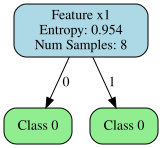

In [4]:
tree = DecisionTree(max_depth=1)
column = "x1"
strategy = lambda x,y : (column , columns.index(column))
tree.custom_fit(df_x, y_df, strategy=strategy)
tree.plot()

In [5]:
preds = tree.predict(X)
error = 1 - accuracy_score(y, preds)
print(f"Error rate: {error:.4f}")

Error rate: 0.3750
